# Final Model Analysis - Customer Segmentation

This notebook provides a consolidated view of the model selection process, hyperparameter tuning, and detailed performance evaluation. 
It combines the evaluation depth and visual styling of the reference performance matrix with the dataset and feature selection logic specific to this project.

### Import Required Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from sklearn import metrics 

warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)

# Load the Customer Segmentation data
df = pd.read_csv(r"D:\Project\Customer_Categorizer_Project\notebooks\data\clustered_data.csv")
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (2240, 22)


c:\Users\Sahil Rathore\.conda\envs\venv\lib\site-packages\xgboost\compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Feature Selection and Train-Test Split

In [2]:
X = df.drop("cluster", axis=1)
y = df["cluster"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (1792, 21), Test size: (448, 21)


## 1. Baseline Performance Analysis (Untuned)

The results below show baseline performance. Note that Hidden Markov Models and Conditional Random Fields are not applicable to this tabular data structure and are included as placeholders.

In [3]:
def evaluate_models(X_train, X_test, y_train, y_test, models_dict):
    results = []
    for name, model in models_dict.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred) * 100
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0) * 100
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0) * 100
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0) * 100

        results.append({
            'Model_name': name,
            'Accuracy %': round(acc, 2),
            'Precision %': round(prec, 2),
            'Recall %': round(rec, 2),
            'F1 %': round(f1, 2),
            'Support': len(y_test)
        })
    return pd.DataFrame(results)

baseline_models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "XGBClassifier": XGBClassifier(random_state=42),
    "support vector machine": SVC(random_state=42)
}

report = evaluate_models(X_train, X_test, y_train, y_test, baseline_models)

# Add HMM and CRF placeholders as requested
placeholders = pd.DataFrame([
    {"Model_name": "Hidden Markov Model", "Accuracy %": np.nan, "Precision %": np.nan, "Recall %": np.nan, "F1 %": np.nan, "Support": np.nan},
    {"Model_name": "Conditional Random Field", "Accuracy %": np.nan, "Precision %": np.nan, "Recall %": np.nan, "F1 %": np.nan, "Support": np.nan}
])

report = pd.concat([report, placeholders], ignore_index=True)
report.sort_values('Accuracy %', ascending=False, na_position='last')

,Model_name,Accuracy %,Precision %,Recall %,F1 %,Support
0,Random Forest,96.88,96.92,96.88,96.88,448.0
2,XGBClassifier,96.65,96.75,96.65,96.67,448.0
1,Logistic Regression,87.72,87.92,87.72,87.75,448.0
3,support vector machine,72.99,72.81,72.99,72.71,448.0
4,Hidden Markov Model,NaN,NaN,NaN,NaN,NaN
5,Conditional Random Field,NaN,NaN,NaN,NaN,NaN


### Performance Visualization

Comparison of algorithms across multiple metrics using the standard color palette.

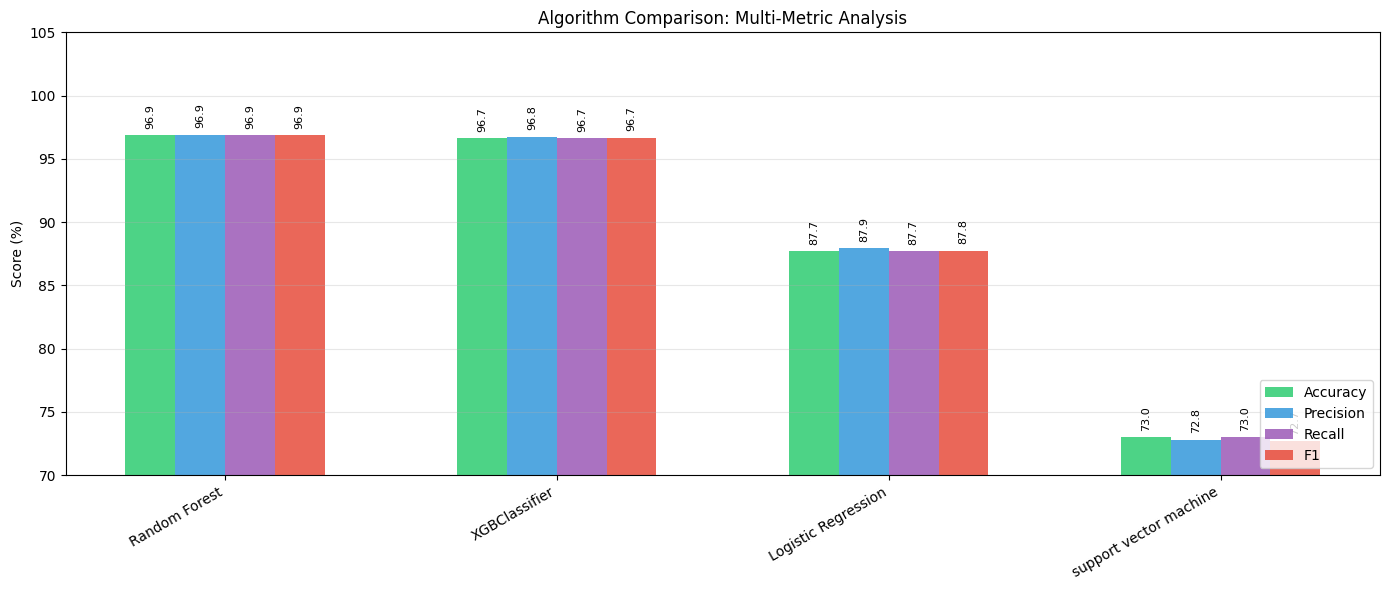

In [4]:
df_plot = report.dropna(subset=["Accuracy %"]).sort_values("Accuracy %", ascending=False)
models_list = df_plot["Model_name"].tolist()
x = np.arange(len(models_list))
bar_width = 0.15

metrics_cols = ["Accuracy %", "Precision %", "Recall %", "F1 %"]
labels = ["Accuracy", "Precision", "Recall", "F1"]
colors_bar = ["#2ecc71", "#3498db", "#9b59b6", "#e74c3c"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (col, label) in enumerate(zip(metrics_cols, labels)):
    offset = (i - 1.5) * bar_width
    bars = ax.bar(x + offset, df_plot[col], bar_width, label=label, color=colors_bar[i], alpha=0.85)
    
    for j, val in enumerate(df_plot[col]):
        ax.text(x[j] + offset, val + 0.5, f"{val:.1f}", ha="center", va="bottom", fontsize=8, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=30, ha="right")
ax.set_ylabel("Score (%)")
ax.set_ylim(70, 105)
ax.set_title("Algorithm Comparison: Multi-Metric Analysis")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Hyperparameter Tuning & Final Model

Systematic optimization of Logistic Regression and visualization of the final confusion matrix.

In [7]:
param_grids = {
    "Random Forest": {"model": RandomForestClassifier(random_state=42), "params": {"n_estimators": [100, 200], "max_depth": [10, 20, None]}},
    "Logistic Regression": {"model": LogisticRegression(max_iter=1000, random_state=42), "params": {"C": [0.1, 1, 10], "solver": ["lbfgs", "liblinear"]}},
    "XGBClassifier": {"model": XGBClassifier(random_state=42), "params": {"n_estimators": [50, 100], "max_depth": [3, 5]}},
    "support vector machine": {"model": SVC(random_state=42), "params": {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"]}}
}

tuned_models = {}
for name, config in param_grids.items():
    print(f"Tuning {name}...")
    gs = GridSearchCV(config["model"], config["params"], cv=3, n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned_models[name] = gs.best_estimator_
    print(f"  Best CV score: {gs.best_score_:.4f}")

# Results reporting for all tuned models
support_total = len(y_test)
results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0) * 100
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0) * 100
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0) * 100
    results.append({"Model_name": name, "Accuracy %": round(acc, 2), "Precision %": round(prec, 2), "Recall %": round(rec, 2), "F1 %": round(f1, 2), "Support": support_total})
    print(f"{name}: Accuracy {acc:.2f}%  Precision {prec:.2f}%  Recall {rec:.2f}%  F1 {f1:.2f}%  Support {support_total}")

report_tuned = pd.DataFrame(results)

report_tuned = pd.concat([
    report_tuned,
    pd.DataFrame([
        {"Model_name": "Hidden Markov Model", "Accuracy %": np.nan, "Precision %": np.nan, "Recall %": np.nan, "F1 %": np.nan, "Support": np.nan},
        {"Model_name": "Conditional Random Field", "Accuracy %": np.nan, "Precision %": np.nan, "Recall %": np.nan, "F1 %": np.nan, "Support": np.nan},
    ])
], ignore_index=True)
print("\nTuned Model Report:")
display(report_tuned.sort_values("Accuracy %", ascending=False, na_position="last"))

# Delta performance assessment (compared to Section 1 report)
untuned = report.dropna(subset=["Accuracy %"])[["Model_name", "Accuracy %", "Precision %", "Recall %", "F1 %"]].copy()
tuned = report_tuned.dropna(subset=["Accuracy %"])[["Model_name", "Accuracy %", "Precision %", "Recall %", "F1 %"]].copy()
untuned = untuned.rename(columns={"Accuracy %": "Acc (untuned)", "Precision %": "Prec (untuned)", "Recall %": "Recall (untuned)", "F1 %": "F1 (untuned)"})
tuned = tuned.rename(columns={"Accuracy %": "Acc (tuned)", "Precision %": "Prec (tuned)", "Recall %": "Recall (tuned)", "F1 %": "F1 (tuned)"})
delta_df = untuned.merge(tuned, on="Model_name")
for m in ["Acc", "Prec", "Recall", "F1"]:
    delta_df[f"?{m}"] = delta_df[f"{m} (tuned)"] - delta_df[f"{m} (untuned)"]
cols = ["Model_name", "Acc (untuned)", "Acc (tuned)", "?Acc", "Prec (untuned)", "Prec (tuned)", "?Prec", "Recall (untuned)", "Recall (tuned)", "?Recall", "F1 (untuned)", "F1 (tuned)", "?F1"]
delta_table = delta_df[cols].sort_values("?Acc", ascending=False).round(2)
print("\nDelta = (tuned ? untuned). Positive ? means tuning improved the metric.\n")
display(delta_table)



Tuning Random Forest...
  Best CV score: 0.9637
Tuning Logistic Regression...
  Best CV score: 0.9481
Tuning XGBClassifier...
  Best CV score: 0.9682
Tuning support vector machine...
  Best CV score: 0.9124
Random Forest: Accuracy 97.10%  Precision 97.17%  Recall 97.10%  F1 97.11%  Support 448
Logistic Regression: Accuracy 95.54%  Precision 95.61%  Recall 95.54%  F1 95.55%  Support 448
XGBClassifier: Accuracy 96.65%  Precision 96.69%  Recall 96.65%  F1 96.66%  Support 448
support vector machine: Accuracy 91.74%  Precision 92.00%  Recall 91.74%  F1 91.78%  Support 448

Tuned Model Report:


,Model_name,Accuracy %,Precision %,Recall %,F1 %,Support
0,Random Forest,97.10,97.17,97.10,97.11,448.0
2,XGBClassifier,96.65,96.69,96.65,96.66,448.0
1,Logistic Regression,95.54,95.61,95.54,95.55,448.0
3,support vector machine,91.74,92.00,91.74,91.78,448.0
4,Hidden Markov Model,NaN,NaN,NaN,NaN,NaN
5,Conditional Random Field,NaN,NaN,NaN,NaN,NaN



Delta = (tuned ? untuned). Positive ? means tuning improved the metric.



,Model_name,Acc (untuned),Acc (tuned),?Acc,Prec (untuned),Prec (tuned),?Prec,Recall (untuned),Recall (tuned),?Recall,F1 (untuned),F1 (tuned),?F1
3,support vector machine,72.99,91.74,18.75,72.81,92.00,19.19,72.99,91.74,18.75,72.71,91.78,19.07
1,Logistic Regression,87.72,95.54,7.82,87.92,95.61,7.69,87.72,95.54,7.82,87.75,95.55,7.80
0,Random Forest,96.88,97.10,0.22,96.92,97.17,0.25,96.88,97.10,0.22,96.88,97.11,0.23
2,XGBClassifier,96.65,96.65,0.00,96.75,96.69,-0.06,96.65,96.65,0.00,96.67,96.66,-0.01


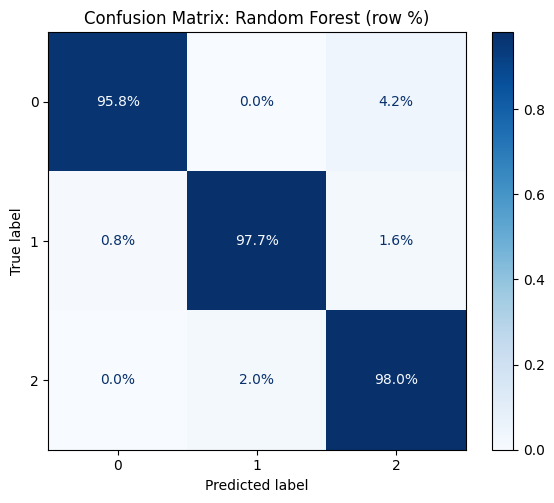

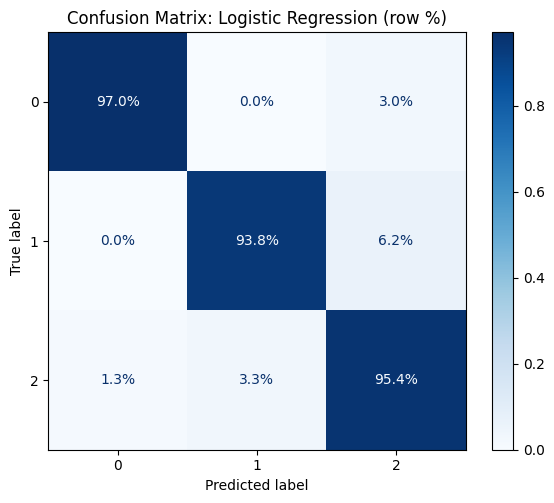

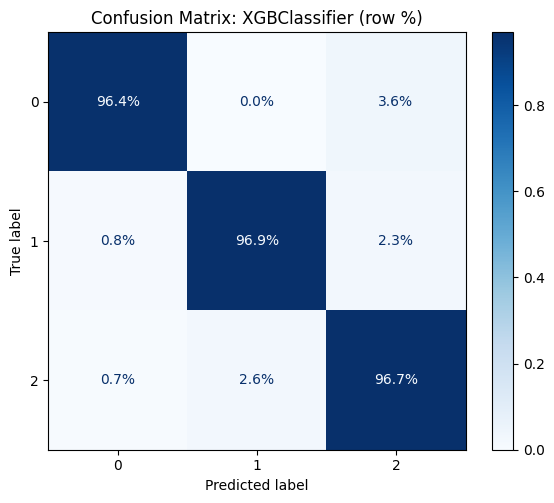

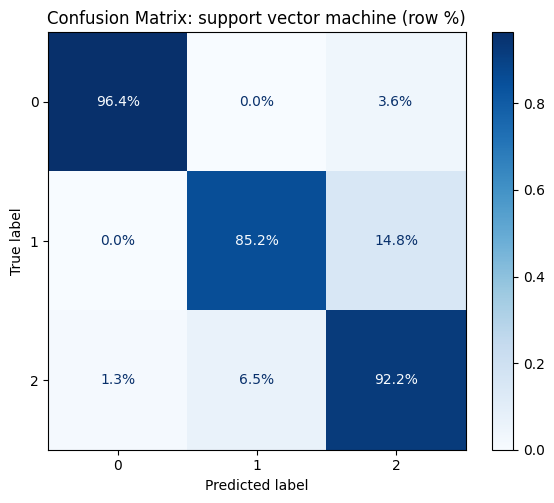

In [6]:
# Plot Confusion Matrices for all tuned models
cmap = plt.cm.Blues
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax, cmap=cmap,
        normalize="true", values_format=".1%"
    )
    ax.set_title(f"Confusion Matrix: {name} (row %)")
    plt.tight_layout()
    plt.show()

## 3. Strategic Insights: Feature Importance

Identifying the key variables that drive customer segmentation.

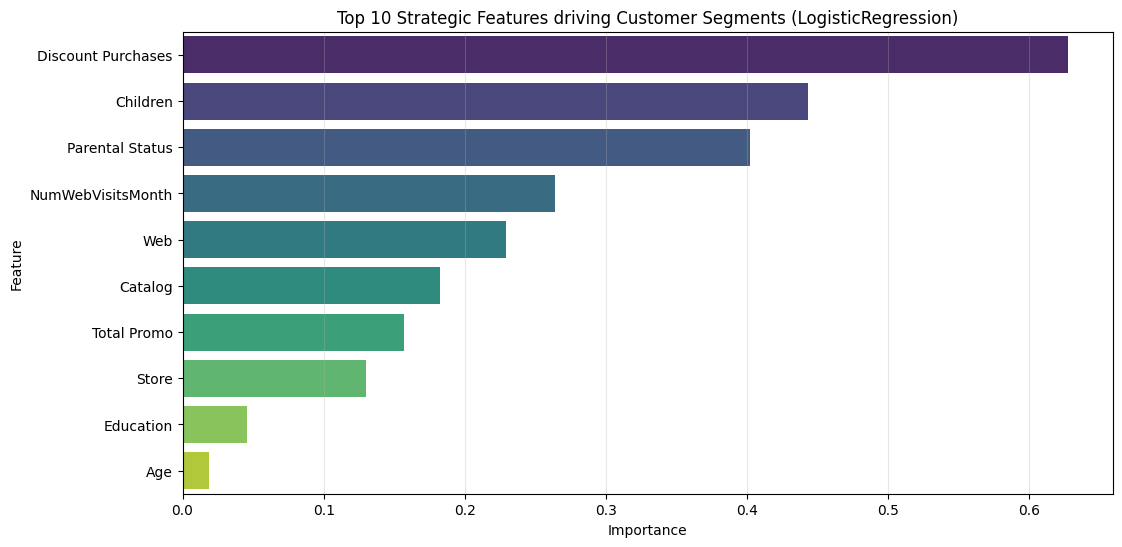

In [8]:
# Select Logistic Regression as the best model as per user request
best_model = tuned_models["Logistic Regression"]

if hasattr(best_model, "feature_importances_"):
    importance = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    # Logistic Regression uses coefficients for importance
    importance = np.abs(best_model.coef_).mean(axis=0)
else:
    importance = np.zeros(X.shape[1])

feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": importance})
feature_importance = feature_importance.sort_values("Importance", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance, palette="viridis")
plt.title(f"Top 10 Strategic Features driving Customer Segments ({type(best_model).__name__})")
plt.grid(axis="x", alpha=0.3)
plt.show()


## 4. Model Export

In [9]:
model_path = "model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)
print(f"Production-ready model ({type(best_model).__name__}) saved at: {model_path}")

Production-ready model (LogisticRegression) saved at: model.pkl
